In [175]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [176]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [177]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [178]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

# GSM

In [179]:
main_path = "../GSM/solns_runs/Ex7/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]


## Number of starting points vs. PDP and HD

In [180]:
folders= ["../GSM/solns_runs/Ex7/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../GSM/solns_runs/Ex7/N_100/',
 '../GSM/solns_runs/Ex7/N_200/',
 '../GSM/solns_runs/Ex7/N_300/',
 '../GSM/solns_runs/Ex7/N_400/',
 '../GSM/solns_runs/Ex7/N_500/',
 '../GSM/solns_runs/Ex7/N_600/',
 '../GSM/solns_runs/Ex7/N_700/',
 '../GSM/solns_runs/Ex7/N_800/',
 '../GSM/solns_runs/Ex7/N_900/',
 '../GSM/solns_runs/Ex7/N_1000/',
 '../GSM/solns_runs/Ex7/N_1100/',
 '../GSM/solns_runs/Ex7/N_1200/',
 '../GSM/solns_runs/Ex7/N_1300/',
 '../GSM/solns_runs/Ex7/N_1400/',
 '../GSM/solns_runs/Ex7/N_1500/']

In [181]:
# folders['n_runs_5']

In [182]:
import os

def list_txt_files_in_directory(directory_path):
#     try:
#         # List all files and directories in the specified path
    files_and_directories = os.listdir(directory_path)
#     print(directory_path)
    # Filter and print only .txt files
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [183]:

n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
#             solns = solns[(solns[:, 0] >= 0) & (solns[:, 0] <= 1)]
            solns= np.array(solns)
            
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        print(len(distinct_points),len(res_solns))
        
        # Get HD:
        
        points = [(t, 1 - t) for t in np.linspace(0, 1, len(distinct_points))]

#         # Print the result
        points= np.array(points)
        

#         print(points.shape, distinct_points.shape)
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../GSM/solns_runs/Ex6/plot_ex6.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

558 1000
1142 2000
1704 3000
2261 4000
2826 5000
3363 6000
3965 7000
4492 8000
5058 9000
5639 10000
6188 11000
6754 12000
7400 13000
7844 14000
8451 15000


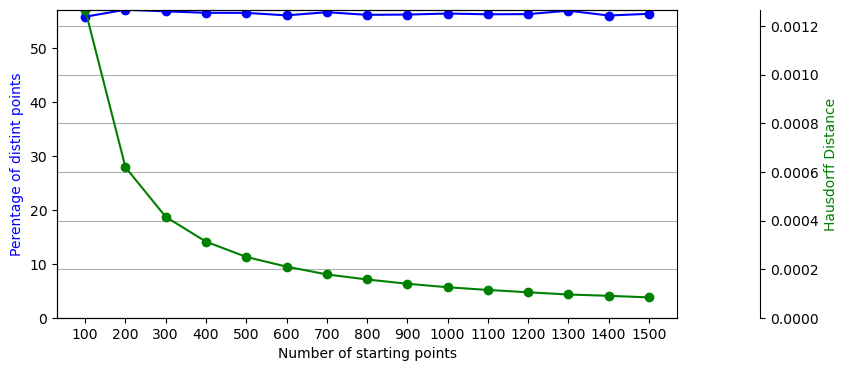

In [184]:
pdpgsm, hdgsm= get_values(folders)

In [185]:
for (p,h) in zip(pdpgsm, hdgsm):
    print(p, " * ", h)

55.800000000000004  *  0.0012672553452390506
57.099999999999994  *  0.000619110719210811
56.8  *  0.0004150272214547736
56.525000000000006  *  0.0003128786498292358
56.52  *  0.00025023411807208114
56.05  *  0.00021031463414290262
56.64285714285714  *  0.0001782523882772606
56.15  *  0.00015735647284748018
56.2  *  0.0001397791914536626
56.38999999999999  *  0.00012541221419369285
56.25454545454546  *  0.00011427840725279573
56.28333333333333  *  0.0001046888645234652
56.92307692307692  *  9.555525691029197e-05
56.028571428571425  *  9.014816818361693e-05
56.34  *  8.366922539469217e-05


In [186]:
max(pdpgsm), min(hdgsm)

(57.099999999999994, 8.366922539469217e-05)

## Histograms

In [187]:
# n_runs= 50 and 

n_points= nubmer_points_list[np.argmax(pdpgsm)] # 15
print(n_points)
# Best
directory_path = "../GSM/solns_runs/Ex7/N_{}".format(n_points)
all_solnsgsm= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsgsm.extend(solns.tolist())

all_solnsgsm= np.array(all_solnsgsm)
# allsolnsgsm = all_solnsgsm[(all_solnsgsm[:, 0] >= 0) & (all_solnsgsm[:, 0] <= 1)]

num, all_solnsgsm = count_repeated_points(all_solnsgsm)
all_solnsgsm= np.array(all_solnsgsm)
print(len(all_solnsgsm))

200
1142


In [188]:
all_solnsgsm

array([[0.19360726, 0.80639274],
       [0.32542018, 0.67457982],
       [0.48532072, 0.51467928],
       ...,
       [0.9701255 , 0.0298745 ],
       [0.51244858, 0.48755142],
       [0.20680173, 0.79319827]])

In [189]:
len(all_solnsgsm)
print(all_solnsgsm)

[[0.19360726 0.80639274]
 [0.32542018 0.67457982]
 [0.48532072 0.51467928]
 ...
 [0.9701255  0.0298745 ]
 [0.51244858 0.48755142]
 [0.20680173 0.79319827]]


In [190]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value < bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsgsm.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 1-x
y_min = np.min(y)
y_max = np.max(y)
# y

xgsm= x.copy()
ygsm= y.copy()

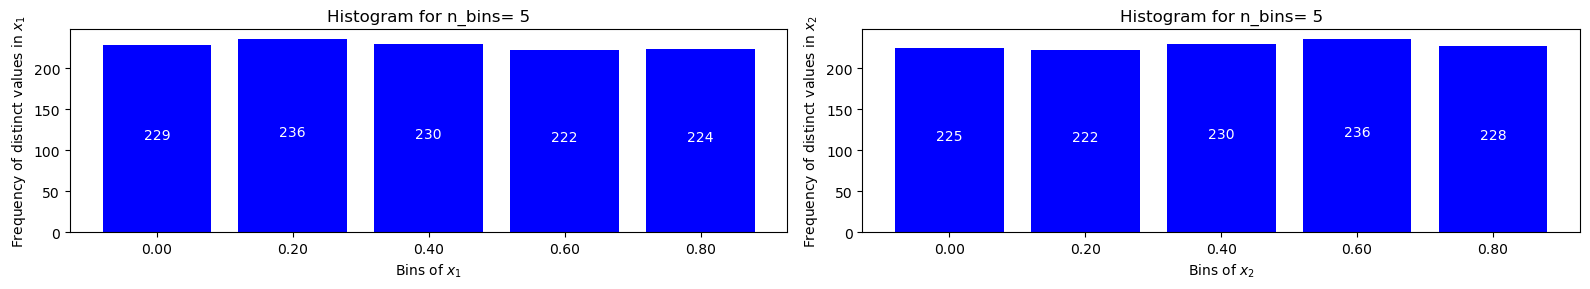

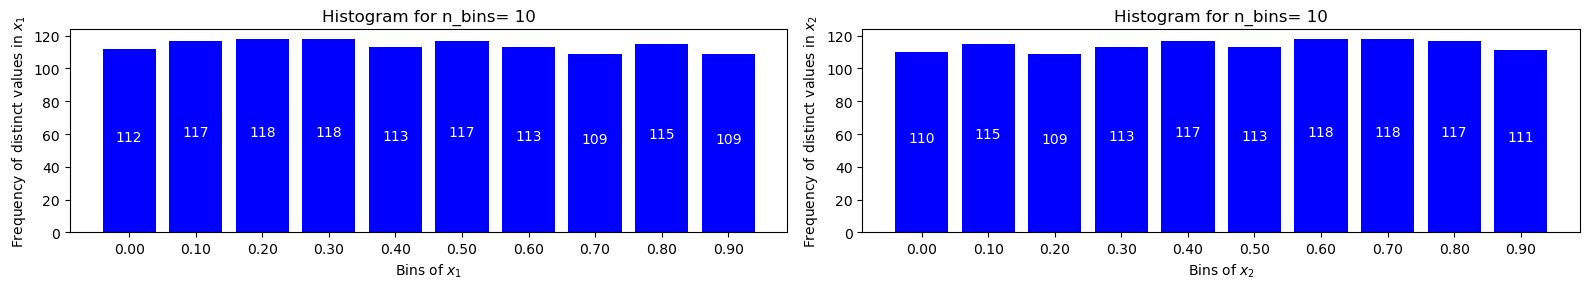

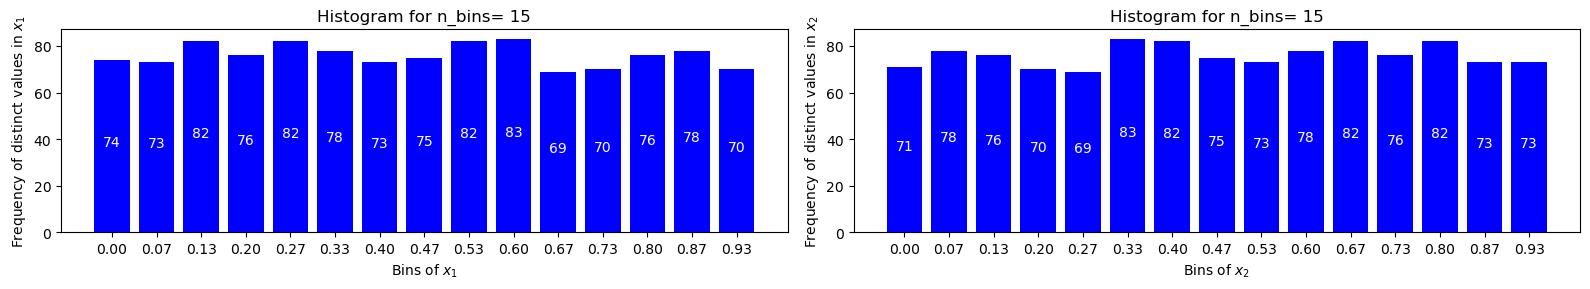

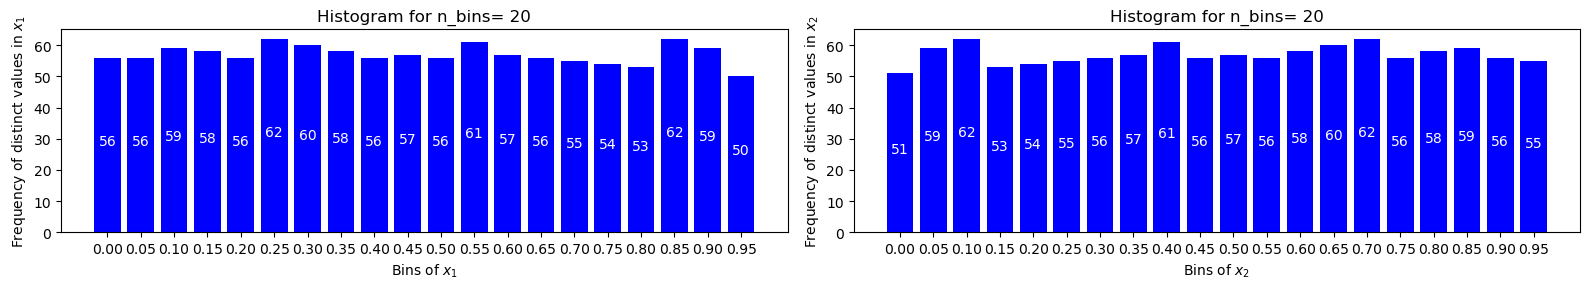

In [191]:
x_hist_gsm= []
y_hist_gsm= []
y_part_gsm= []
x_part_gsm= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_gsm.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_gsm.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_gsm.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_gsm.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../GSM/solns_runs/Ex6/'+'ex6_gsm_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF

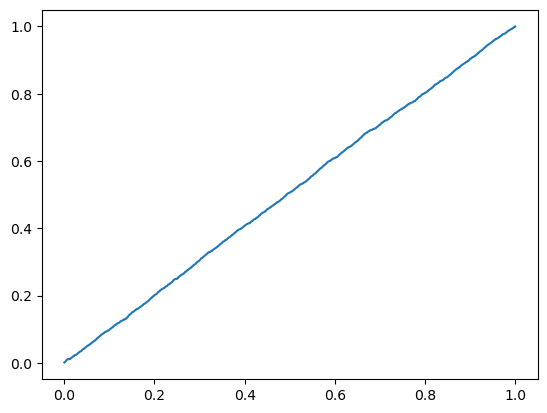

In [192]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF
# fit a cdf
ecdf = ECDF(xgsm)
plt.plot(ecdf.x, ecdf.y)
plt.show()


def get_cdf_of_uniform(x, a, b):
    if x<a:
        return 0
    elif a<=x<b:
        return (x-a)/(b-a)
    elif x>b:
        return 1

## KS-Test

In [193]:
import numpy as np
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
data = np.random.uniform(0,1, size=100)

# Perform KS test against a normal distribution (null hypothesis)
ks_statistic, p_value = stats.kstest(data, 'norm')

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis that the data is normally distributed.")
else:
    print("Cannot reject the null hypothesis that the data is normally distributed.")


KS Statistic: 0.5018732170965315
P-value: 7.902176095057781e-24
Reject the null hypothesis that the data is normally distributed.


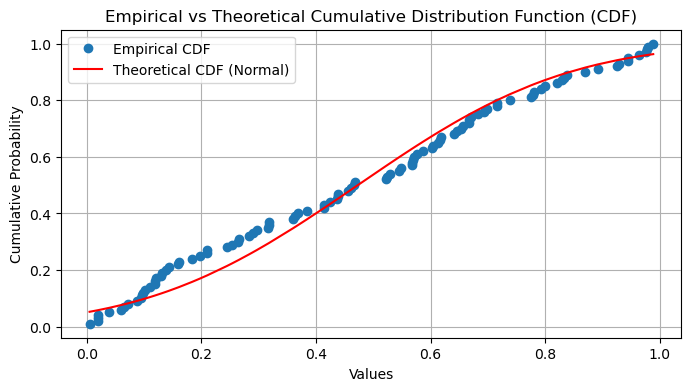

In [194]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
# data = np.random.normal(loc=0, scale=1, size=100)

# Sort the data
sorted_data = np.sort(data)

# Calculate the empirical CDF
n = sorted_data.size
y_empirical = np.arange(1, n+1) / n

# Calculate the theoretical CDF (normal distribution)
mean, std = np.mean(data), np.std(data)
y_theoretical = stats.norm.cdf(sorted_data, loc=mean, scale=std)

# Plotting the empirical and theoretical CDFs
plt.figure(figsize=(8, 4))
plt.plot(sorted_data, y_empirical, label='Empirical CDF', marker='o', linestyle='none')
plt.plot(sorted_data, y_theoretical, label='Theoretical CDF (Normal)', color='red')
plt.xlabel('Values')
plt.ylabel('Cumulative Probability')
plt.title('Empirical vs Theoretical Cumulative Distribution Function (CDF)')
plt.legend()
plt.grid(True)
plt.show()


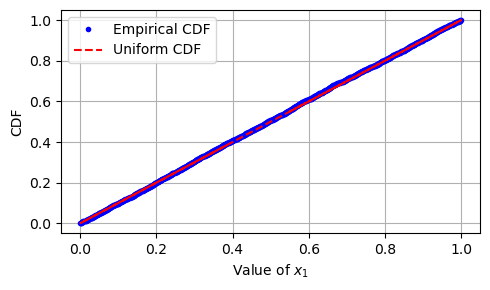

K-S Statistic: 0.015358163549147097
P-Value: 0.9466306544667246
Fail to reject the null hypothesis: The sample follows the uniform distribution.


In [195]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
#uniform_samples= np.hstack((uniform_samples,5.0))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xgsm)
ecdf_gsm_x = ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_x.x, ecdf_gsm_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([5.0],[1], 'r--')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex7/ks_ex6_x1.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(xgsm, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
ks_statistic, p_value = stats.kstest(xgsm, 'uniform', args=(a, b))
# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [196]:
ecdf_gsm_x.y

array([0.00000000e+00, 8.75656743e-04, 1.75131349e-03, ...,
       9.98248687e-01, 9.99124343e-01, 1.00000000e+00])

In [197]:
ecdf_gsm_x.x

array([          -inf, 4.79636258e-04, 1.10404904e-03, ...,
       9.97076135e-01, 9.97505478e-01, 9.99570268e-01])

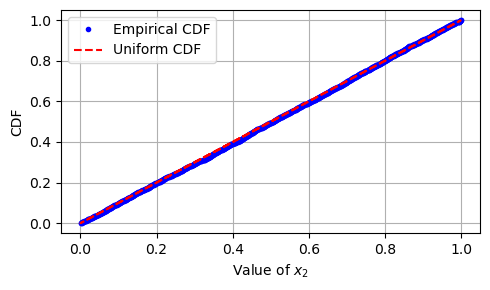

K-S Statistic: 0.015358163549147097
P-Value: 0.9466306544667246
Fail to reject the null hypothesis: The sample follows the uniform distribution.


In [198]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(x)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ygsm)
ecdf_gsm_y = ECDF(ygsm) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex6/ks_ex6_x2.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(ygsm, "uniform")
ks_statistic, p_value = stats.kstest(ygsm, 'uniform', args=(a, b))

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


In [199]:
# y

# PVI

In [200]:
# New

## Load data

def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0] + x[1])])

import json

# with open('../Scripts/PVI/Ex3PVI.json') as f:
#     data= json.load(f)

with open('../Scripts/PVI/Ex6PVIT.json') as f:
    dataT= json.load(f)

T_list= [1, 2, 3, 4, 5, 6, 7]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)

data_dict



for T in T_list:
    data_all= []

    for i in range(len(nubmer_points_list)):
        res_= []

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            
            for t in range(len(dataT[str(T)][i])):
                #print(data[str(i)][t])
                # if np.all(np.abs(const(x[i+1])) <= 1e-6):
                if np.all(np.abs(constraint_function(dataT[str(T)][i][t]))< 1e-4):
                    res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all


res_all= []

for i in range(len(nubmer_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)

data_all= res_all

In [201]:
data= []
dist_= []
avg_hd= []

for (idx, pt) in enumerate(nubmer_points_list):
    dt= []
    

    num_points= nubmer_points_list[idx]

    num, distinct_points = count_repeated_points(np.array(data_all[idx]))
    distinct_points= np.array(distinct_points)  

    points = [(t, 1 - t) for t in np.linspace(0, 1, num_points)]
    points= np.array(points)
    
    
    hausdorff_distance = directed_hausdorff(np.array(data_all[idx]), points)[0]
    dist_.append((len(distinct_points)/(len(data_all[idx])))*100)
    avg_hd.append(hausdorff_distance)

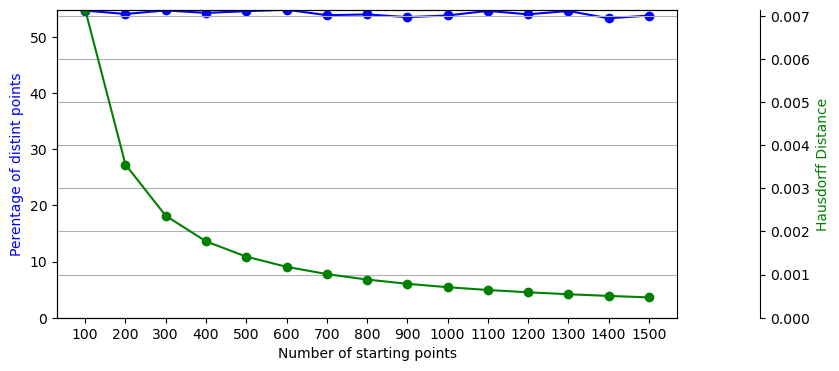

In [202]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Create second axis with different scale
ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
ax1.set_ylim([0.0, np.max(dist_)])
ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


# Create third axis with different scale
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
ax2.plot(nubmer_points_list, avg_hd, 'go-')
ax2.set_ylabel('Hausdorff Distance', color='g')
ax2.set_ylim([0.0, np.max(avg_hd)])

xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


plt.savefig('../PVI/solns_runs/Ex7/plot_ex7.png')
plt.grid(True)
plt.show()

In [203]:
pdppvi, hdgpvi= dist_.copy(),avg_hd.copy()

In [204]:
for (p,h) in zip(pdppvi,hdgpvi):
    print(p, " *** ", h)

54.67625899280576  ***  0.007139710158418869
54.06654343807763  ***  0.0035514294252395272
54.71349353049908  ***  0.002363261237331454
54.260299625468164  ***  0.0017703723453513709
54.56909361069836  ***  0.0014161600473695424
54.82989064398542  ***  0.0011804543793406252
53.858226523672506  ***  0.001011549766320662
53.98917392327607  ***  0.0008849704298794297
53.51374029788126  ***  0.0007865255516875892
53.80266277585264  ***  0.0007076473000351904
54.62481114655028  ***  0.0006429263091471854
54.010946051602815  ***  0.0005897076606074034
54.60972850678733  ***  0.00054426643062208
53.304198119454384  ***  0.0005054030362554457
53.791996047430835  ***  0.00047153749223716396


In [205]:
pdppvi_all, hdgpvi_all= dist_.copy(),avg_hd.copy()

In [206]:
# PVI
data= data_all
# solnspvi= np.array(data[14]) #np.genfromtxt("../PVI/Ex5"+"/"+"solnsEx5.txt", delimiter=',') #np.array(solns) #sol
solnspvi= np.array(data[np.argmax(pdppvi)]) #np.genfromtxt("../PVI/Ex5"+"/"+"solnsEx5.txt", delimiter=',') #np.array(solns) #sol

num, distinct_points = count_repeated_points(solnspvi)
solnspvi= np.array(distinct_points)
solnspvi

array([[0.52418923, 0.47580617],
       [0.563046  , 0.43694952],
       [0.55453198, 0.4454635 ],
       ...,
       [0.84709416, 0.15290369],
       [0.88617714, 0.11382102],
       [0.10482154, 0.89517669]])

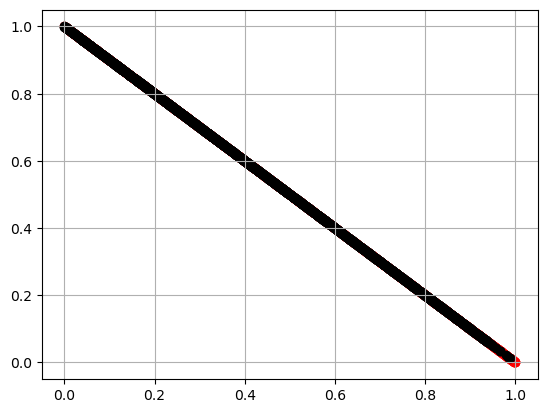

In [207]:
plt.scatter(points[:,0], points[:,1], c= 'red')
plt.scatter(solnspvi[:,0], solnspvi[:,1], c= 'black')

#plt.xlim([0,1.0])
#plt.ylim([0,1.0])
plt.grid(True)
plt.show()

In [208]:
pdppvi, hdgpvi= dist_.copy(),avg_hd.copy()

In [209]:
max(dist_), min(avg_hd)

(54.82989064398542, 0.00047153749223716396)

In [210]:
# Best npoint
n_points= nubmer_points_list[np.argmax(pdppvi)] # 1500
sol= np.array(data[np.argmax(pdppvi)])
sol = sol[(sol[:, 0] >= 0) & (sol[:, 0] <= 1)]
num, sol = count_repeated_points(sol)
sol= np.array(sol)
print(sol)

[[0.52418923 0.47580617]
 [0.563046   0.43694952]
 [0.55453198 0.4454635 ]
 ...
 [0.84709416 0.15290369]
 [0.88617714 0.11382102]
 [0.10482154 0.89517669]]


## Histogram

In [211]:
## x:
bins_list= [5, 10, 15, 20]
solns= sol.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 1-x
y_min = np.min(y)
y_max = np.max(y)
# y

xpvi= x.copy()
ypvi= y.copy()

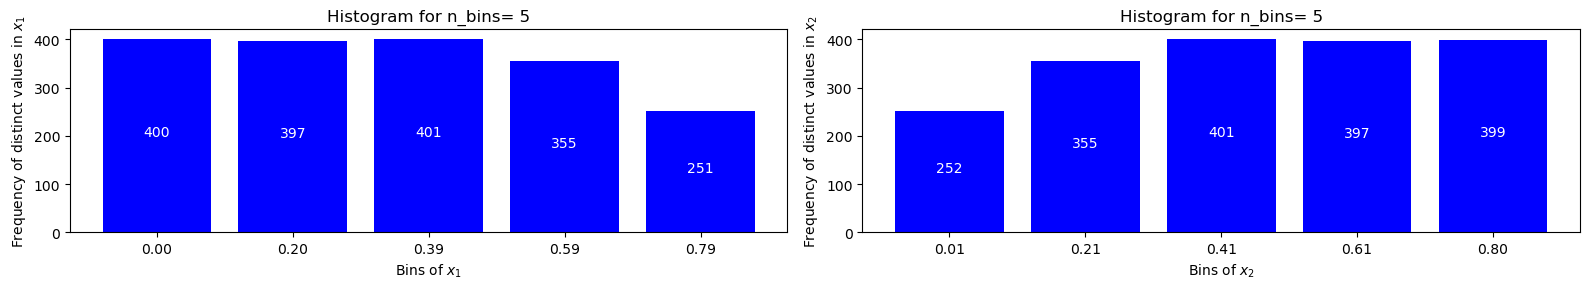

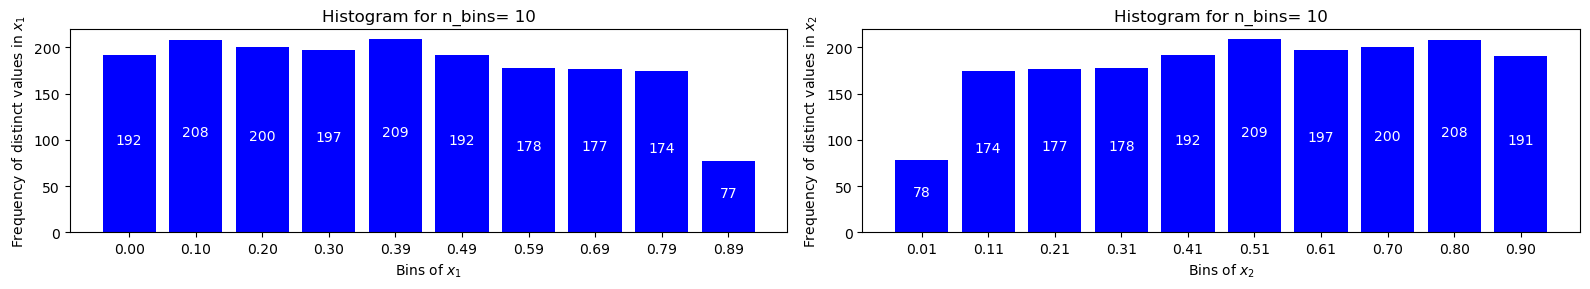

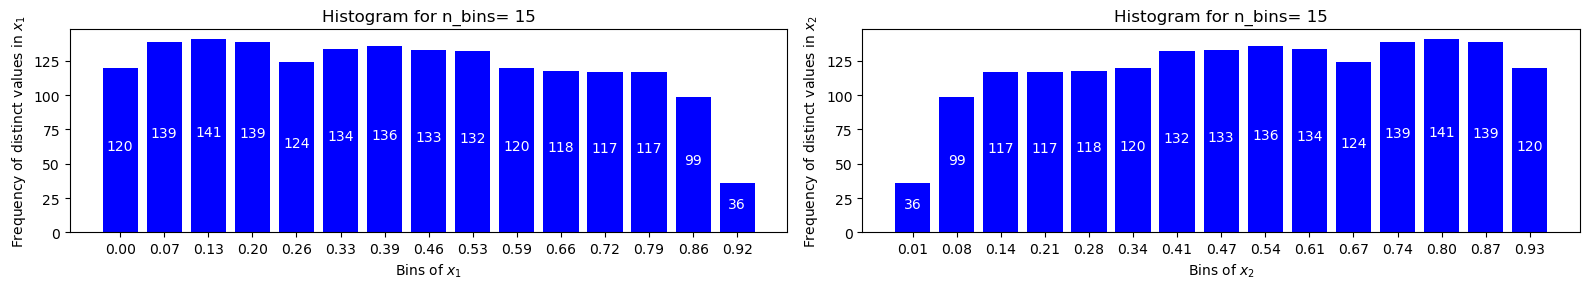

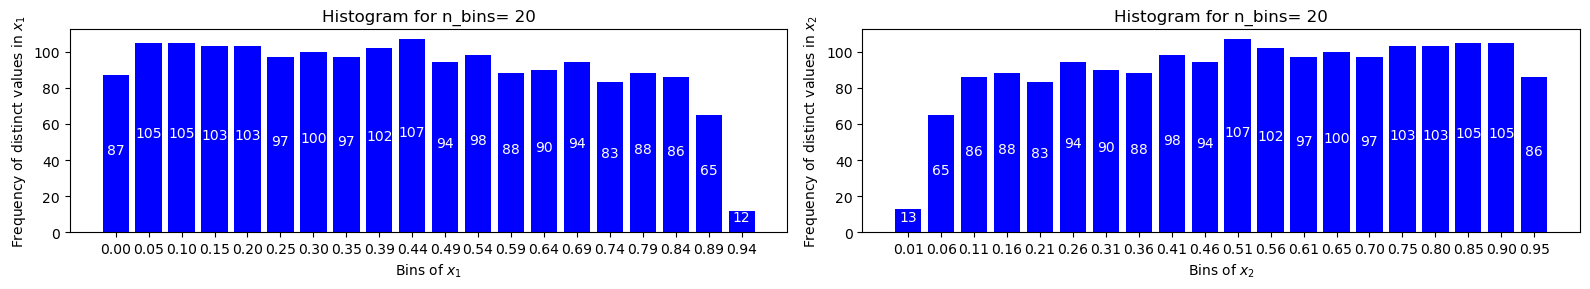

In [212]:
x_hist_pvi= []
y_hist_pvi= []
y_part_pvi= []
x_part_pvi= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_pvi.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_pvi.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_pvi.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_pvi.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../PVI/solns_runs/Ex6/'+'ex6_pvi_hist'+str(n_bins)+'.png')
    plt.show()

In [213]:
for (p,h) in zip(pdppvi, hdgpvi):
    print(p, " * ", h)

54.67625899280576  *  0.007139710158418869
54.06654343807763  *  0.0035514294252395272
54.71349353049908  *  0.002363261237331454
54.260299625468164  *  0.0017703723453513709
54.56909361069836  *  0.0014161600473695424
54.82989064398542  *  0.0011804543793406252
53.858226523672506  *  0.001011549766320662
53.98917392327607  *  0.0008849704298794297
53.51374029788126  *  0.0007865255516875892
53.80266277585264  *  0.0007076473000351904
54.62481114655028  *  0.0006429263091471854
54.010946051602815  *  0.0005897076606074034
54.60972850678733  *  0.00054426643062208
53.304198119454384  *  0.0005054030362554457
53.791996047430835  *  0.00047153749223716396


## Uniform CDF vs. empirical CDF and KS-Test

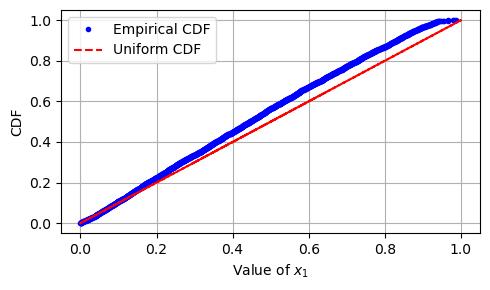

K-S Statistic: 0.07547238486713193
P-Value: 2.1805779328399977e-09
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [214]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xpvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xpvi)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xpvi)
ecdf_pvi_x = ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_x.x, ecdf_pvi_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../PVI/solns_runs/Ex6/ks_ex6_x1.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(xpvi, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
ks_statistic, p_value = stats.kstest(xpvi, 'uniform', args=(a, b))
# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

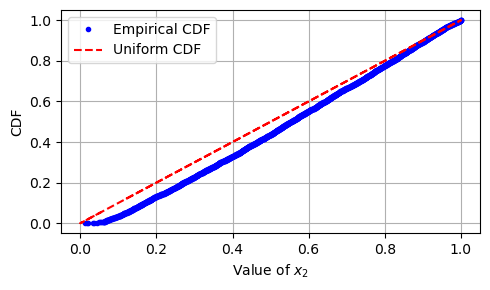

K-S Statistic: 0.07547238486713195
P-Value: 2.1805779328399646e-09
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [215]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(ypvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ypvi)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ypvi)
ecdf_gsm_y = ECDF(ypvi) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../PVI/solns_runs/Ex6/ks_ex6_x2.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(ypvi, "uniform")
ks_statistic, p_value = stats.kstest(ypvi, 'uniform', args=(a, b))
# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


### Number of starting points vs. PDP and HD

# BFGS

In [216]:
def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

### Number of starting points vs. PDP and HD

In [217]:
main_path = "../Merit/solns_runs/Ex7/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../Merit/solns_runs/Ex6/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../Merit/solns_runs/Ex6/N_100/',
 '../Merit/solns_runs/Ex6/N_200/',
 '../Merit/solns_runs/Ex6/N_300/',
 '../Merit/solns_runs/Ex6/N_400/',
 '../Merit/solns_runs/Ex6/N_500/',
 '../Merit/solns_runs/Ex6/N_600/',
 '../Merit/solns_runs/Ex6/N_700/',
 '../Merit/solns_runs/Ex6/N_800/',
 '../Merit/solns_runs/Ex6/N_900/',
 '../Merit/solns_runs/Ex6/N_1000/',
 '../Merit/solns_runs/Ex6/N_1100/',
 '../Merit/solns_runs/Ex6/N_1200/',
 '../Merit/solns_runs/Ex6/N_1300/',
 '../Merit/solns_runs/Ex6/N_1400/',
 '../Merit/solns_runs/Ex6/N_1500/']

In [218]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            solns = solns[(solns[:, 0] >= 0) & (solns[:, 1] >= 0)]
            solns = solns[(solns[:, 0] <= 1)]
            solns= np.array(solns)
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        alpha= 1.0
        points = [(t, 1 - t) for t in np.linspace(-alpha, alpha, len(distinct_points))]

#         # Print the result
        points= np.array(points)
        

        
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        print(len(distinct_points),len(res_solns), ': ', hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex7/plot_ex6.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

421 881 :  0.0033576075355588922
887 1814 :  0.0015961649796310963
1300 2708 :  0.0010884995988786484
1730 3610 :  0.0008176200821152532
2190 4482 :  0.0006456327085584436
2651 5416 :  0.0005335498783669979
3249 6265 :  0.0004353193464100541
3609 7102 :  0.00039181317306845136
4182 8096 :  0.0003380682411247602
4336 8907 :  0.0003261214671359451
4718 9856 :  0.0002997958194499989
5187 10683 :  0.0002726845518998609
6000 11657 :  0.0002356589964073437
6484 12562 :  0.00021813996573904825
6835 13374 :  0.000206930559043999


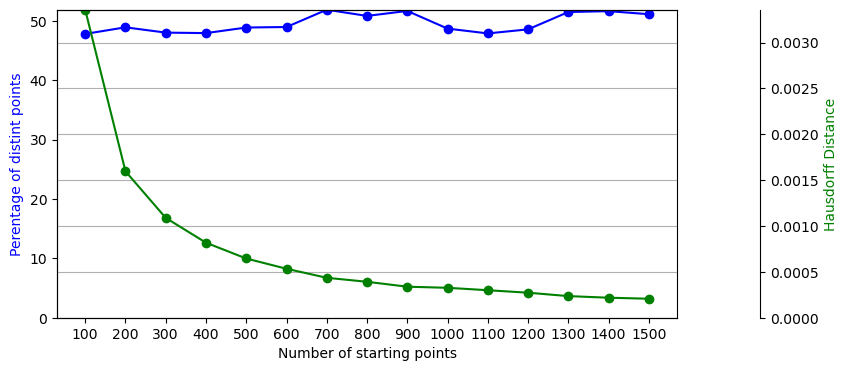

In [219]:
pdpbfgs, hdbfgs= get_values(folders)

In [220]:
for (p,h) in zip(pdpbfgs,hdbfgs):
    print(p, " * ", h)

47.786606129398415  *  0.0033576075355588922
48.89746416758545  *  0.0015961649796310963
48.005908419497786  *  0.0010884995988786484
47.92243767313019  *  0.0008176200821152532
48.86211512717537  *  0.0006456327085584436
48.94756277695716  *  0.0005335498783669979
51.859537110933765  *  0.0004353193464100541
50.81667136018023  *  0.00039181317306845136
51.655138339920946  *  0.0003380682411247602
48.680812843830694  *  0.0003261214671359451
47.86931818181818  *  0.0002997958194499989
48.55377702892446  *  0.0002726845518998609
51.47121901003688  *  0.0002356589964073437
51.61598471580958  *  0.00021813996573904825
51.106624794377154  *  0.000206930559043999


In [221]:
max(pdpbfgs), min(hdbfgs)

(51.859537110933765, 0.000206930559043999)

In [222]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
       
        res= []
        for file in files:
            if "._" in file:
                file= file.replace("._", "")
            solns= np.genfromtxt(file, delimiter=',')
            solns = solns[(solns[:, 0] >= 0) & (solns[:, 1] >= 0)]
            solns = solns[(solns[:, 0] <= 1)]
            
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
#             break
            
        all_solns.append(res)
        
    
#     print(np.array(all_solns[0])[:,0])
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
#         solns= np.genfromtxt(ex1_path+solutions[i], delimiter=',')
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
#         plt.xlim([0,1.0])
#         plt.ylim([0,1.0])
        plt.grid(True)
        plt.show()

In [223]:
# plot_solns(folders)

### Histograms

In [224]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpbfgs)] #1500
# Best
directory_path = "../Merit/solns_runs/Ex6/N_{}".format(n_points)
all_solnsbfgs= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')
    solns = solns[(solns[:, 0] >= 0) & (solns[:, 1] >= 0)]
    solns = solns[(solns[:, 0] <= 1)]
    # solns = solns[(solns[:, 0] <= 1) & (solns[:, 1] <= 1)]

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsbfgs.extend(solns.tolist())

all_solnsbfgs= np.array(all_solnsbfgs)
# all_solnsbfgs = all_solnsbfgs[(all_solnsbfgs[:, 0] >= 0) & (all_solnsbfgs[:, 0] <= 1)]

num, all_solnsbfgs = count_repeated_points(all_solnsbfgs)
all_solnsbfgs= np.array(all_solnsbfgs)

In [225]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsbfgs.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xbfgs= x.copy()
ybfgs= y.copy()

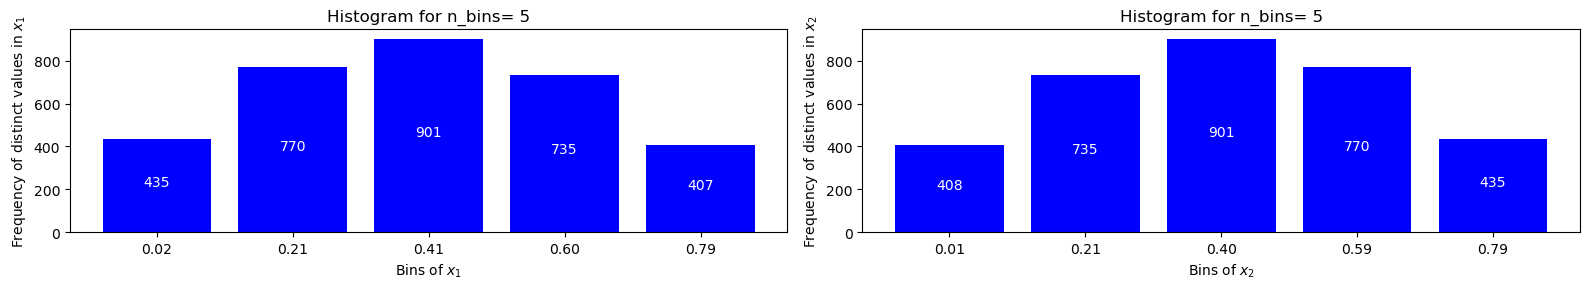

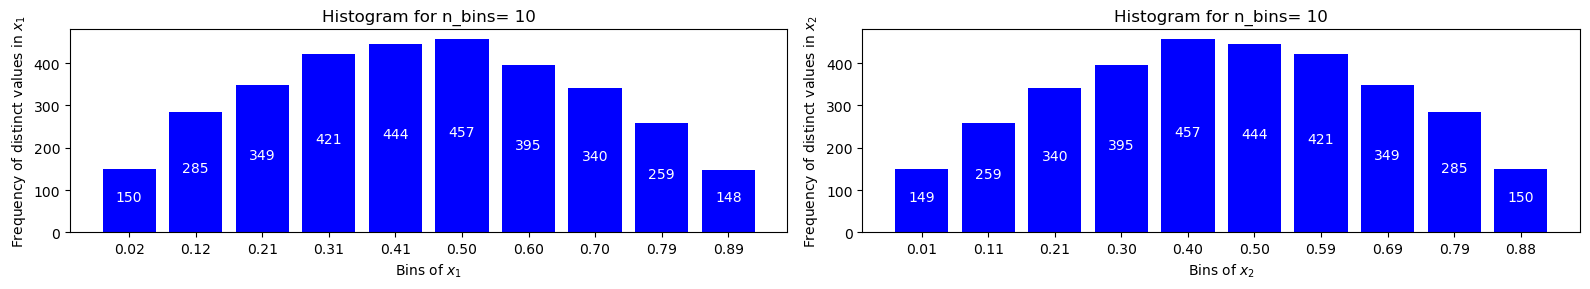

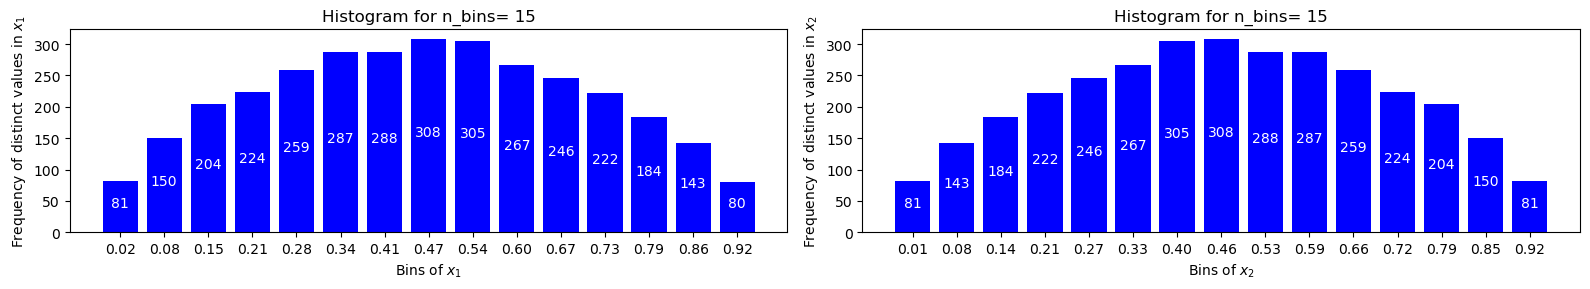

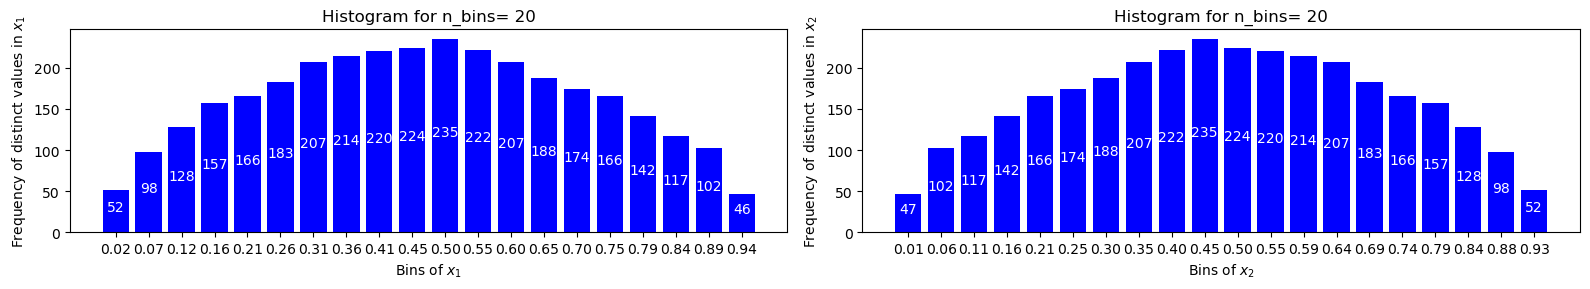

In [226]:
x_hist_bfgs= []
y_hist_bfgs= []
y_part_bfgs= []
x_part_bfgs= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_bfgs.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_bfgs.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_bfgs.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_bfgs.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../Merit/solns_runs/Ex6/'+'ex6_bfgs_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and KS-Test

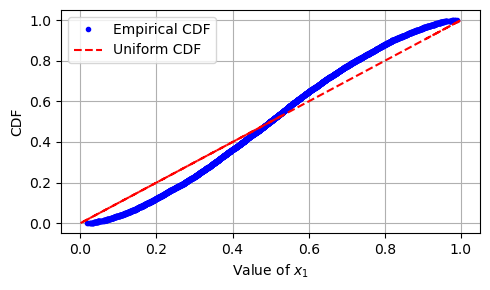

K-S Statistic: 0.08092925249770044
P-Value: 5.87100448494966e-19
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [227]:
 # KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xbfgs)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xbfgs)
ecdf_bfgs_x = ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_x.x, ecdf_bfgs_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex6/ks_ex6_x1.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(xbfgs, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
ks_statistic, p_value = stats.kstest(xbfgs, 'uniform', args=(a, b))
# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

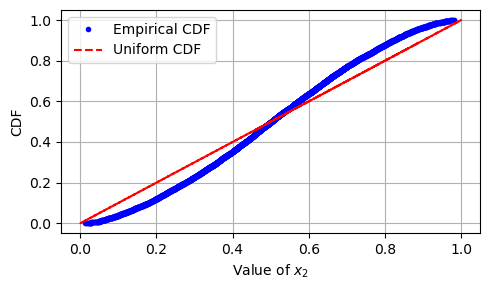

K-S Statistic: 0.08092925249770047
P-Value: 5.871004484949488e-19
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [228]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ybfgs)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ybfgs)
ecdf_bfgs_y = ECDF(ybfgs) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_y.x, ecdf_bfgs_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex6/ks_ex6_x2.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(ybfgs, "uniform")
ks_statistic, p_value = stats.kstest(ybfgs, 'uniform', args=(a, b))

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# EIA

## Number of starting points vs. PDP and HD

In [229]:
main_path = "../EIA/solns_runs/Ex7/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../EIA/solns_runs/Ex7/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../EIA/solns_runs/Ex7/N_100/',
 '../EIA/solns_runs/Ex7/N_200/',
 '../EIA/solns_runs/Ex7/N_300/',
 '../EIA/solns_runs/Ex7/N_400/',
 '../EIA/solns_runs/Ex7/N_500/',
 '../EIA/solns_runs/Ex7/N_600/',
 '../EIA/solns_runs/Ex7/N_700/',
 '../EIA/solns_runs/Ex7/N_800/',
 '../EIA/solns_runs/Ex7/N_900/',
 '../EIA/solns_runs/Ex7/N_1000/',
 '../EIA/solns_runs/Ex7/N_1100/',
 '../EIA/solns_runs/Ex7/N_1200/',
 '../EIA/solns_runs/Ex7/N_1300/',
 '../EIA/solns_runs/Ex7/N_1400/',
 '../EIA/solns_runs/Ex7/N_1500/']

In [230]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
#             solns = solns[(solns[:, 0] >= 0) & (solns[:, 0] <= 1)]
            solns= np.array(solns)
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        points = [(t, 1 - t) for t in np.linspace(0, 1, len(distinct_points))]

#         # Print the result
        points= np.array(points)
        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../EIA/solns_runs/Ex6/plot_ex6.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

426 1000
1014 2000
1541 3000
2069 4000
2676 5000
3278 6000
3816 7000
4385 8000
4949 9000
5525 10000
6096 11000
6736 12000
7140 13000
7812 14000
8324 15000


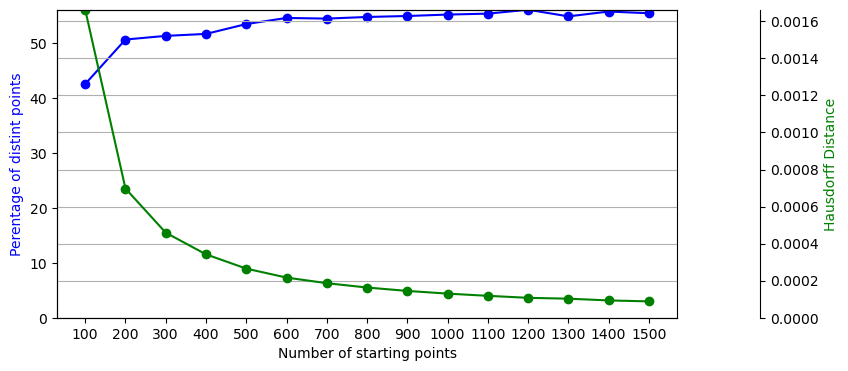

In [231]:
pdpeia, hdeia= get_values(folders)

In [232]:
for (p,h) in zip(pdpeia,hdeia):
    print(p, " * ", h)

42.6  *  0.001662691952881498
50.7  *  0.0006974784951076416
51.366666666666674  *  0.0004591296634104518
51.725  *  0.0003421966846981872
53.52  *  0.0002650849026500535
54.63333333333333  *  0.00021673013073213285
54.51428571428571  *  0.00018637502640495588
54.8125  *  0.00016298913721937548
54.98888888888889  *  0.0001446997634918158
55.25  *  0.00013014316571877127
55.41818181818182  *  0.00011820350399421453
56.13333333333333  *  0.0001074153398763455
54.92307692307692  *  0.00010281463375315055
55.800000000000004  *  9.332357643746331e-05
55.493333333333325  *  8.823630438466977e-05


In [233]:
max(pdpeia), min(hdeia)

(56.13333333333333, 8.823630438466977e-05)

In [234]:
#plot_solns(folders)

### Histograms

In [235]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpeia)]#1500
# Best
directory_path = "../EIA/solns_runs/Ex7/N_{}".format(n_points)
all_solnseia= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnseia.extend(solns.tolist())

all_solnseia= np.array(all_solnseia)
# all_solnseia = all_solnseia[(all_solnseia[:, 0] >= 0) & (all_solnseia[:, 0] <= 1)]

num, all_solnseia = count_repeated_points(all_solnseia)
all_solnseia= np.array(all_solnseia)

In [236]:
bins_list= [5, 10, 15, 20]
solns= all_solnseia.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

# y

xeia= x.copy()
yeia= y.copy()

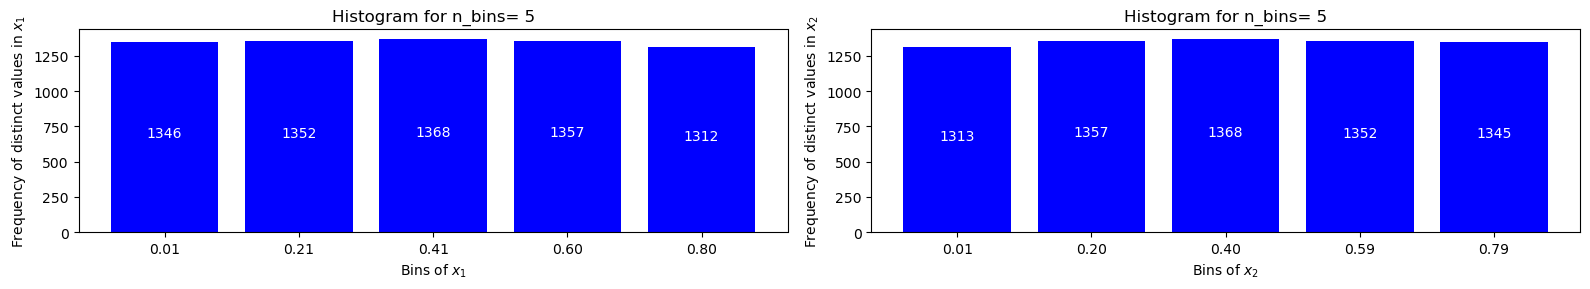

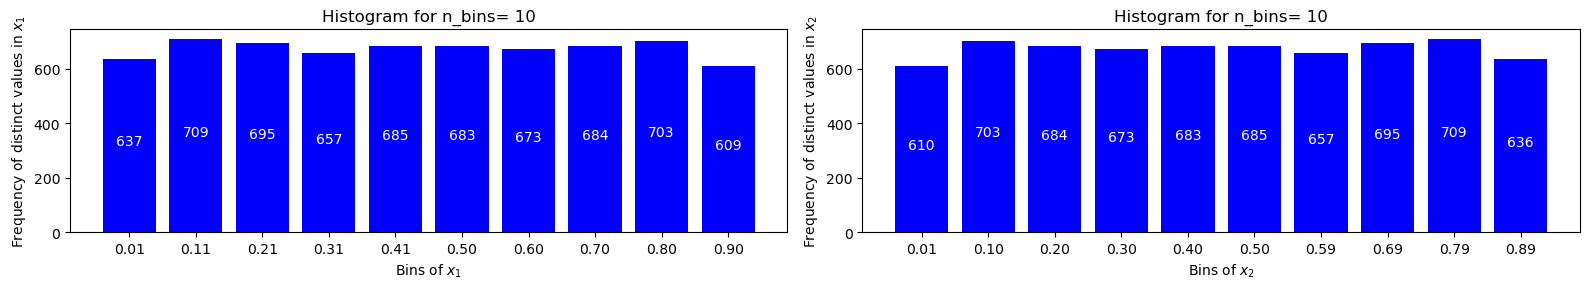

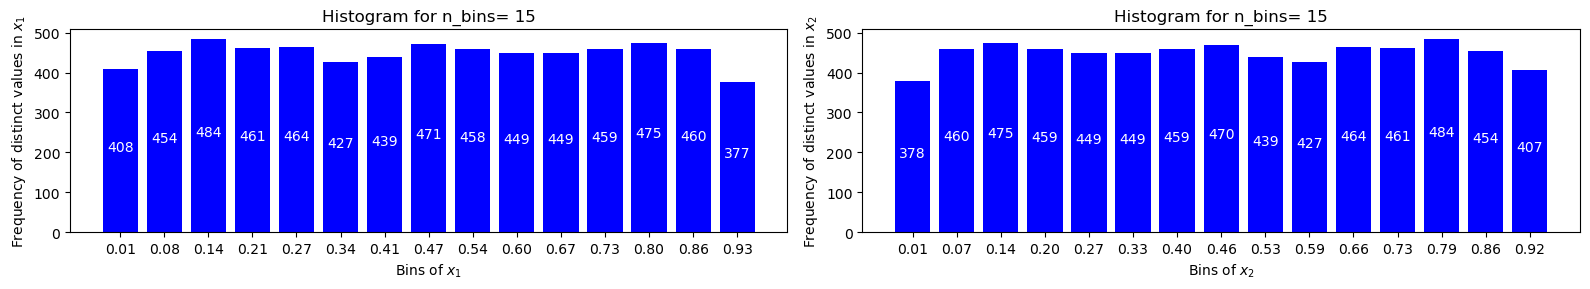

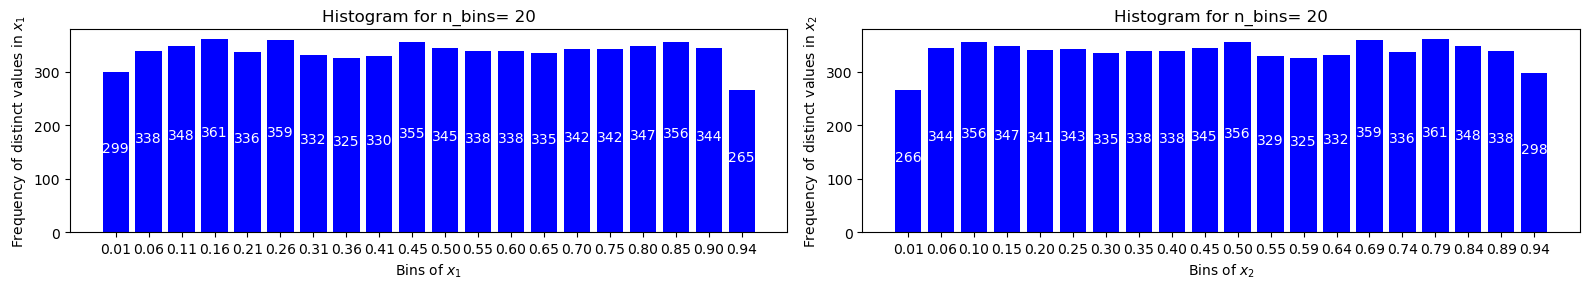

In [237]:
x_hist_eia= []
y_hist_eia= []
y_part_eia= []
x_part_eia= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_eia.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_eia.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_eia.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_eia.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../EIA/solns_runs/Ex6/'+'ex6_eia_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and  KS-Test

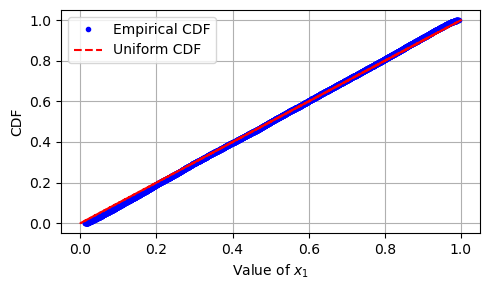

K-S Statistic: 0.01913348511309567
P-Value: 0.014238350790641053
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [238]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xeia)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xeia)
ecdf_eia_x = ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_x.x, ecdf_eia_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex6/ks_ex6_x1.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(xeia, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
ks_statistic, p_value = stats.kstest(xeia, 'uniform', args=(a, b))
# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

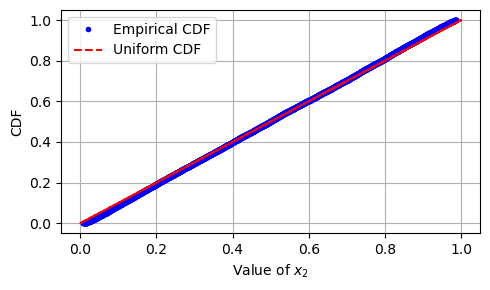

K-S Statistic: 0.019146126630210647
P-Value: 0.014145697857344923
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [239]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(yeia)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(yeia)
ecdf_eia_y = ECDF(yeia) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_y.x, ecdf_eia_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex6/ks_ex6_x2.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(yeia, "uniform")
ks_statistic, p_value = stats.kstest(yeia, 'uniform', args=(a, b))

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [240]:
ks_statistic,p_value

(0.019146126630210647, 0.014145697857344923)

# SGD

In [241]:
main_path = "../SGD/solns_runs/Ex7/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../SGD/solns_runs/Ex7/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../SGD/solns_runs/Ex7/N_100/',
 '../SGD/solns_runs/Ex7/N_200/',
 '../SGD/solns_runs/Ex7/N_300/',
 '../SGD/solns_runs/Ex7/N_400/',
 '../SGD/solns_runs/Ex7/N_500/',
 '../SGD/solns_runs/Ex7/N_600/',
 '../SGD/solns_runs/Ex7/N_700/',
 '../SGD/solns_runs/Ex7/N_800/',
 '../SGD/solns_runs/Ex7/N_900/',
 '../SGD/solns_runs/Ex7/N_1000/',
 '../SGD/solns_runs/Ex7/N_1100/',
 '../SGD/solns_runs/Ex7/N_1200/',
 '../SGD/solns_runs/Ex7/N_1300/',
 '../SGD/solns_runs/Ex7/N_1400/',
 '../SGD/solns_runs/Ex7/N_1500/']

## Number of starting points vs. PDP and HD

In [242]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]
#nubmer_points_list= nubmer_points_list[:10]
nubmer_points_list

[100,
 200,
 300,
 400,
 500,
 600,
 700,
 800,
 900,
 1000,
 1100,
 1200,
 1300,
 1400,
 1500]

In [243]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        
        #print(pt)
        #print(files)
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')[:nubmer_points_list[pt]]#[:,:-1]
            solns = solns[(solns[:, 0] >= 0) & (solns[:, 1]>= 0)]
            solns = solns[(solns[:, 0] <= 1) & (solns[:, 1]<= 1)]
#             solns = solns[(solns[:, 0] >= 0) & (solns[:, 1]>= 0)]
            mask= solns[:,-1]<2.5
            solns= solns[mask][:,:-1]
            solns= np.array(solns)
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        print(res_solns.shape)
        
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        alpha= 1.0

        # Define the range of alpha values
        alpha_values = np.random.uniform(-alpha, alpha, len(distinct_points))

        # Generate the set of (alpha, 1 - alpha) tuples
        points = [(alpha, 1 - alpha) for alpha in alpha_values]

#         # Print the result
#         print(result)

#         points = [(t, 1 - t) for t in np.linspace(-alpha, alpha, len(distinct_points))]
# #         points = [(t, 1 - t) for t in np.linspace(0, 1, num_points)]

#         # Print the result
        points= np.array(points)
#         print(distinct_points)
        

        
        hausdorff_distance= directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        print(len(distinct_points),len(res_solns), ': ', (len(distinct_points)/(len(res_solns)))*100, hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../SGD/solns_runs/Ex6/plot_ex6.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd



# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
#         points = [(t, 1 - t) for t in np.linspace(0, 1, num_points)]

#         # Print the result
#         points= np.array(points)
        
#         for file in files:
#             if "._" in file:
#                 file= file.replace("._","")
#             solns= np.genfromtxt(file, delimiter=',')
#             solns = solns[(solns[:, 0] >= 0) & (solns[:, 0] <= 1)]
#             mask= solns[:,-1]<2.5
#             solns= solns[mask][:,:-1]
#             num, distinct_points = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(nubmer_points_list[pt]))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../SGD/solns_runs/Ex6/plot_ex6.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd

(1000, 2)
516 1000 :  51.6 0.012847099939360108
(2000, 2)
1106 2000 :  55.300000000000004 0.007261879433045103
(3000, 2)
1823 3000 :  60.766666666666666 0.0039874337812401866
(4000, 2)
2618 4000 :  65.45 0.005774784046167854
(5000, 2)
3496 5000 :  69.92 0.002390161812289878
(6000, 2)
4372 6000 :  72.86666666666667 0.002150560024166204
(7000, 2)
5271 7000 :  75.3 0.0024874260720531174
(8000, 2)
6200 8000 :  77.5 0.0018198587700002445
(9000, 2)
7191 9000 :  79.9 0.0019052114893654182
(10000, 2)
8127 10000 :  81.27 0.0015220603254539756
(11000, 2)
8997 11000 :  81.7909090909091 0.0014406372256992339
(12000, 2)
9972 12000 :  83.1 0.0012726336142202164
(13000, 2)
10998 13000 :  84.6 0.0010563398074581302
(14000, 2)
11994 14000 :  85.67142857142858 0.000970999166117697
(15000, 2)
12918 15000 :  86.11999999999999 0.000837670039907582


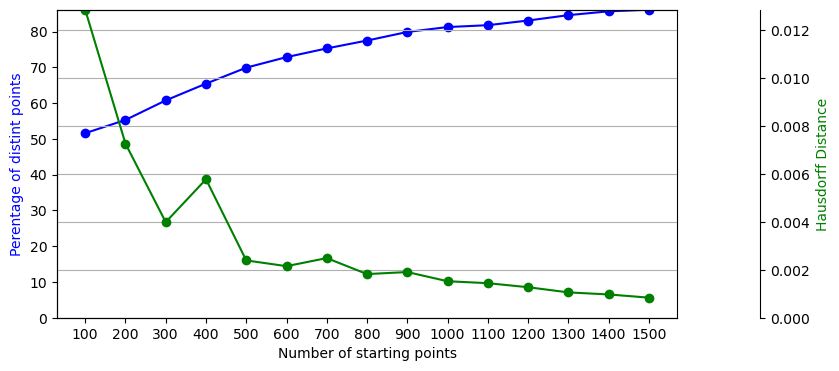

In [244]:
pdpsgd, hdsgd= get_values(folders)

In [245]:
for (p,h) in zip(pdpsgd,hdsgd):
    print(p, " * ", h)

51.6  *  0.012847099939360108
55.300000000000004  *  0.007261879433045103
60.766666666666666  *  0.0039874337812401866
65.45  *  0.005774784046167854
69.92  *  0.002390161812289878
72.86666666666667  *  0.002150560024166204
75.3  *  0.0024874260720531174
77.5  *  0.0018198587700002445
79.9  *  0.0019052114893654182
81.27  *  0.0015220603254539756
81.7909090909091  *  0.0014406372256992339
83.1  *  0.0012726336142202164
84.6  *  0.0010563398074581302
85.67142857142858  *  0.000970999166117697
86.11999999999999  *  0.000837670039907582


In [246]:
max(pdpsgd), min(hdsgd)

(86.11999999999999, 0.000837670039907582)

## Histograms

In [247]:
n_points= nubmer_points_list[np.argmax(pdpsgd)] # 1500
# Best
directory_path = "../SGD/solns_runs/Ex7/N_{}".format(n_points)

all_solnssgd= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:

    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
    solns = solns[(solns[:, 0] >= 0) & (solns[:, 1]>= 0)]
    solns = solns[(solns[:, 0] <= 1) & (solns[:, 1]<= 1)]
    mask= solns[:,-1]<2.5
    solns= solns[mask][:,:-1]
#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    
    all_solnssgd.extend(solns)

all_solnssgd= np.array(all_solnssgd)

num, all_solnssgd = count_repeated_points(all_solnssgd)
all_solnssgd= np.array(all_solnssgd)
all_solnssgd

array([[0.34244104, 0.65731243],
       [0.2051036 , 0.7947562 ],
       [0.63604882, 0.36387835],
       ...,
       [0.80510447, 0.19533774],
       [0.77349762, 0.22642362],
       [0.60100266, 0.39889105]])

In [248]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnssgd.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xsgd= x.copy()
ysgd= y.copy()

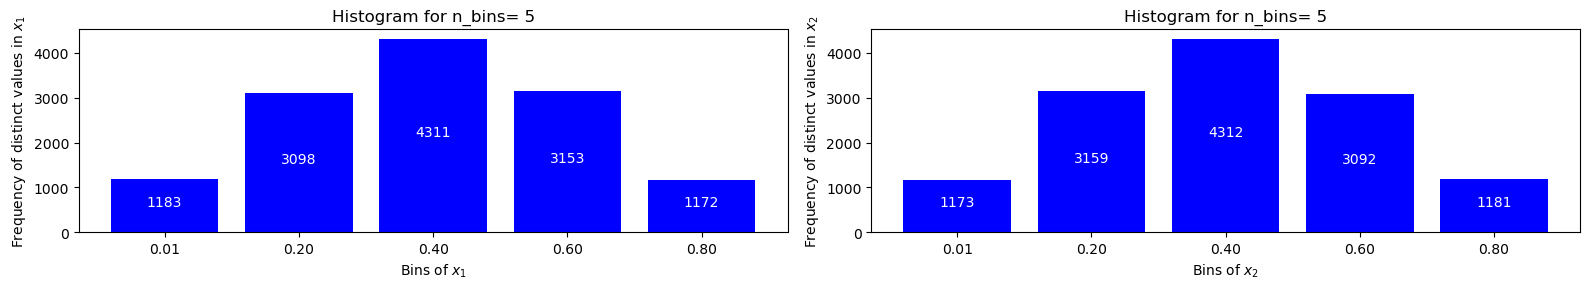

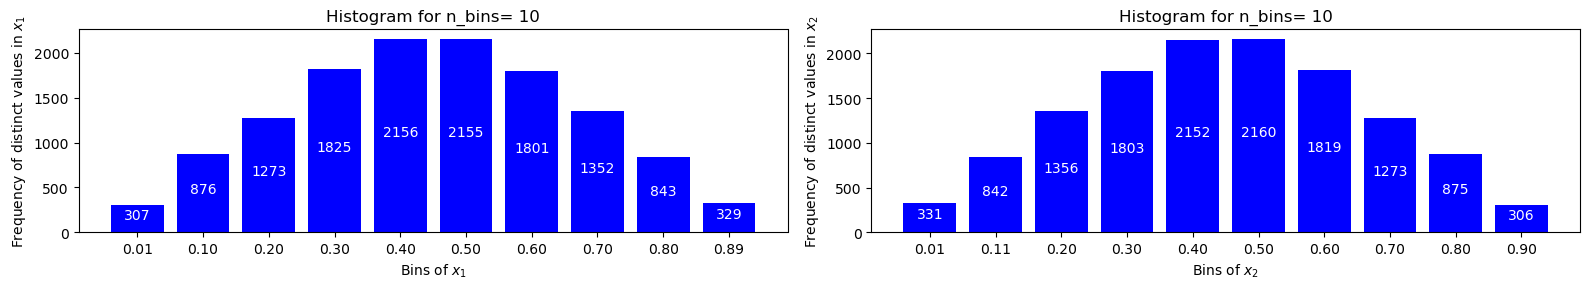

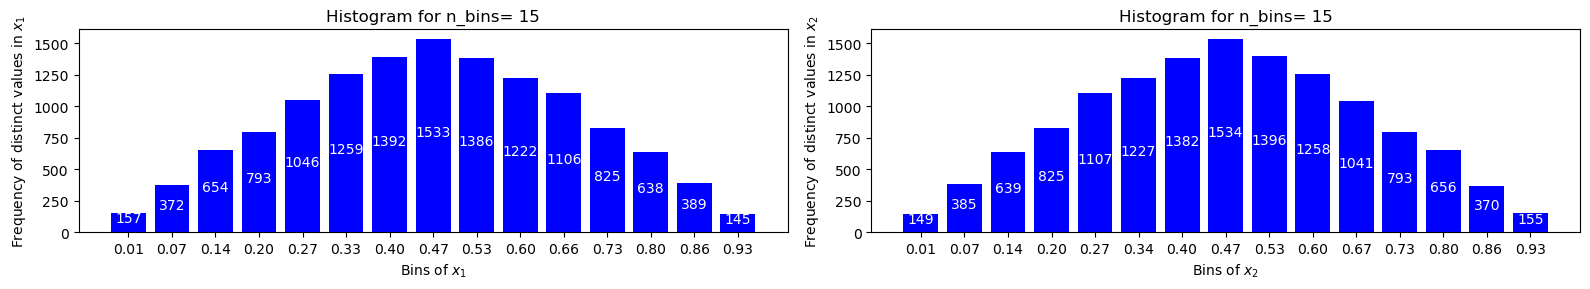

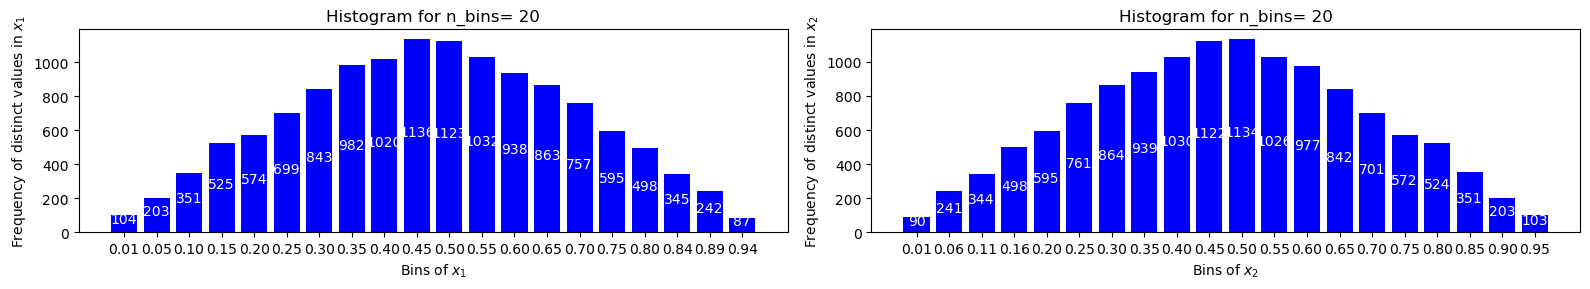

In [249]:
x_hist_sgd= []
y_hist_sgd= []
y_part_sgd= []
x_part_sgd= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_sgd.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_sgd.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_sgd.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_sgd.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../SGD/solns_runs/Ex6/'+'ex6_sgd_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

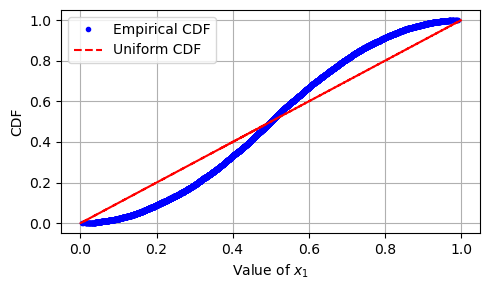

K-S Statistic: 0.11740932207231147
P-Value: 1.3156905054311636e-155
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [250]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xsgd)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xsgd)
ecdf_sgd_x = ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex6/ks_ex6_x1.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(xsgd, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
ks_statistic, p_value = stats.kstest(xsgd, 'uniform', args=(a, b))
# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

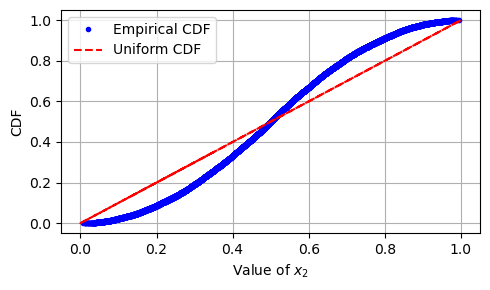

K-S Statistic: 0.11741036405168223
P-Value: 1.3073476490046697e-155
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [251]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(ysgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ysgd)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ysgd)
ecdf_sgd_y = ECDF(ysgd) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex6/ks_ex6_x2.png')
plt.show()

# Perform K-S test
#ks_statistic, p_value = stats.kstest(ysgd, "uniform")
ks_statistic, p_value = stats.kstest(ysgd, 'uniform', args=(a, b))

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# KS-Overall

In [252]:
def KS_test(sample, a, b, alpha=0.05):
    ecdf_sgd_x = ECDF(sample)
    x1 = ecdf_sgd_x.x       # First coordinate
    # ecdf_sgd_y = ECDF(ysgd)
    # x2 = ecdf_sgd_y.x   # Second coordinate
    # print("Algorithm ", name)
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

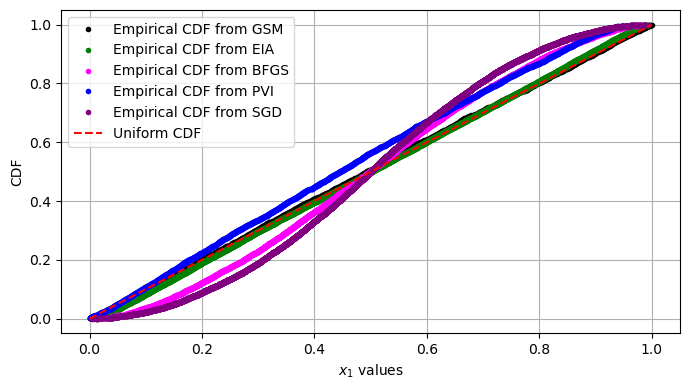

GSM
K-S Statistic: 0.0152
P-Value: 0.9500
Result: Fail to reject H0 → Sample follows Uniform(0.000479636258088334,0.9995702677418068)

*********
EIA
K-S Statistic: 0.0115
P-Value: 0.3365
Result: Fail to reject H0 → Sample follows Uniform(0.012979839928732745,0.9935397055610786)

*********
BFGS
K-S Statistic: 0.0749
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.018244292299581147,0.9884936410142889)

*********
PVI
K-S Statistic: 0.0658
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(8.363939899833055e-09,0.9872324578293058)

*********
SGD
K-S Statistic: 0.1146
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.005131162900272118,0.9928280135125456)

*********


In [253]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
#uniform_samples= np.hstack((uniform_samples,5))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(x)
ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
plt.plot([a, b], [0.0, 1], 'r--', label='Uniform CDF')
# plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex7/all_ks_ex7_x1.png')
plt.show()

print("GSM")
KS_test(xgsm, min(xgsm), max(xgsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(xeia, min(xeia), max(xeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(xbfgs, min(xbfgs), max(xbfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(xpvi, min(xpvi), max(xpvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(xsgd, min(xsgd), max(xsgd), alpha=0.05)
print("*********")

In [254]:
ecdfeia.x,ecdfbfgs.x

(array([      -inf, 0.01297984, 0.01340565, ..., 0.99229545, 0.99278895,
        0.99353971]),
 array([      -inf, 0.01824429, 0.01874374, ..., 0.98335839, 0.98552002,
        0.98849364]))

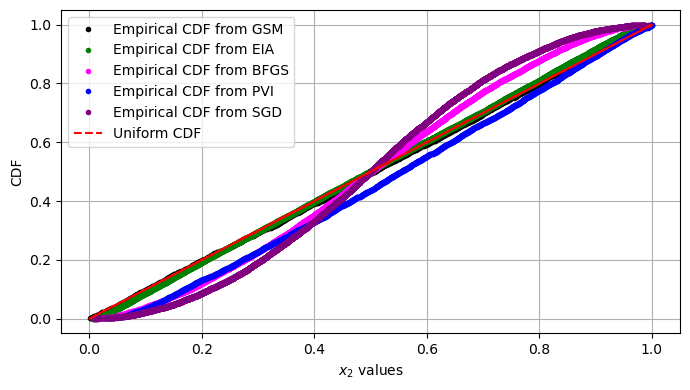

GSM
K-S Statistic: 0.0152
P-Value: 0.9500
Result: Fail to reject H0 → Sample follows Uniform(0.00042973225819320504,0.9995203637419117)

*********
EIA
K-S Statistic: 0.0115
P-Value: 0.3340
Result: Fail to reject H0 → Sample follows Uniform(0.006460292789608325,0.9870201749371623)

*********
BFGS
K-S Statistic: 0.0749
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.011506358985711118,0.9817557077004188)

*********
PVI
K-S Statistic: 0.0658
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.012767542170694202,0.9999999916360601)

*********
SGD
K-S Statistic: 0.1147
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.00736410246157282,0.9949216658468882)

*********


In [255]:
# KS Test on y: 
# Number of samples
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# uniform_samples= np.hstack((uniform_samples,9))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(y)
ecdfgsm= ECDF(ygsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(yeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(ybfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(ypvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(ysgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex7/all_ks_ex7_x2.png')
plt.show()


    
print("GSM")
KS_test(ygsm, min(ygsm), max(ygsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(yeia, min(yeia), max(yeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(ybfgs, min(ybfgs), max(ybfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(ypvi, min(ypvi), max(ypvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(ysgd, min(ysgd), max(ysgd), alpha=0.05)
print("*********")

In [256]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]


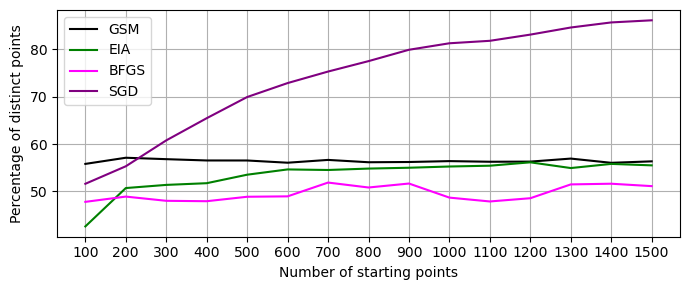

In [257]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, pdpgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, pdpeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, pdpbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, pdppvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, pdpsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Percentage of distinct points')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex7/ex7_npoints_pdp.png')
plt.show()

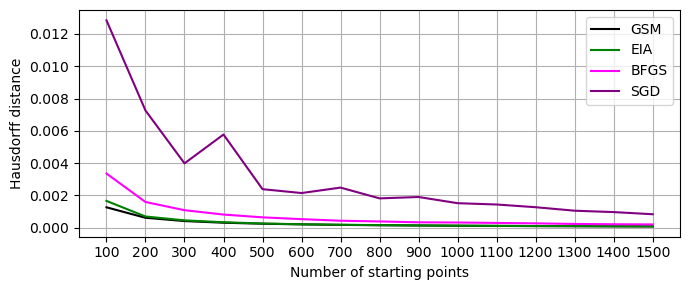

In [258]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, hdgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, hdeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, hdbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, hdgpvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, hdsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Hausdorff distance')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex7/ex7_npoints_hd.png')
plt.show()

In [259]:
hdgpvi

[0.007139710158418869,
 0.0035514294252395272,
 0.002363261237331454,
 0.0017703723453513709,
 0.0014161600473695424,
 0.0011804543793406252,
 0.001011549766320662,
 0.0008849704298794297,
 0.0007865255516875892,
 0.0007076473000351904,
 0.0006429263091471854,
 0.0005897076606074034,
 0.00054426643062208,
 0.0005054030362554457,
 0.00047153749223716396]

# Histograms

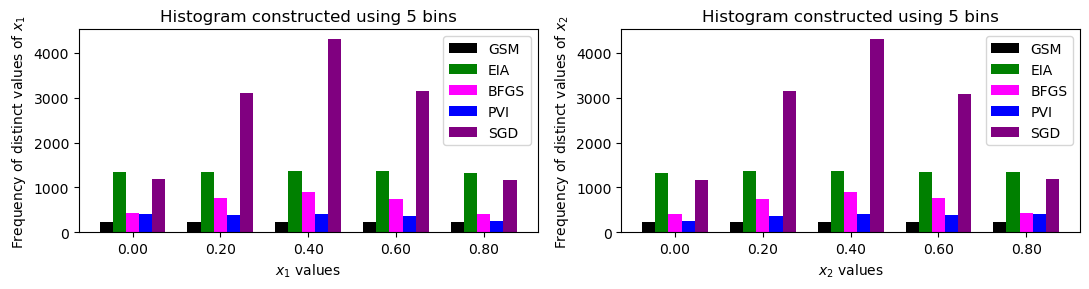

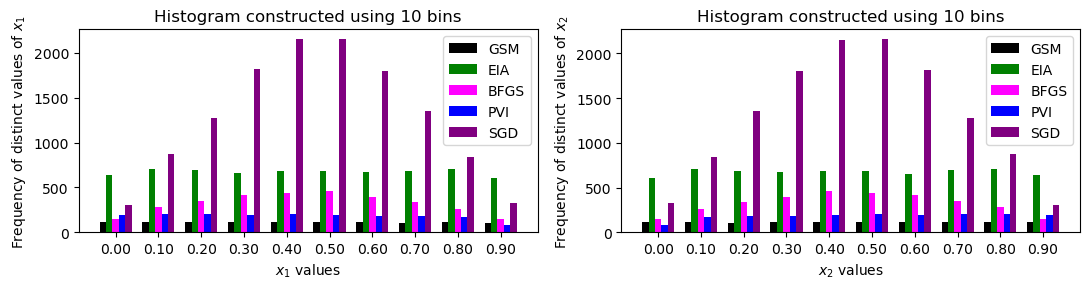

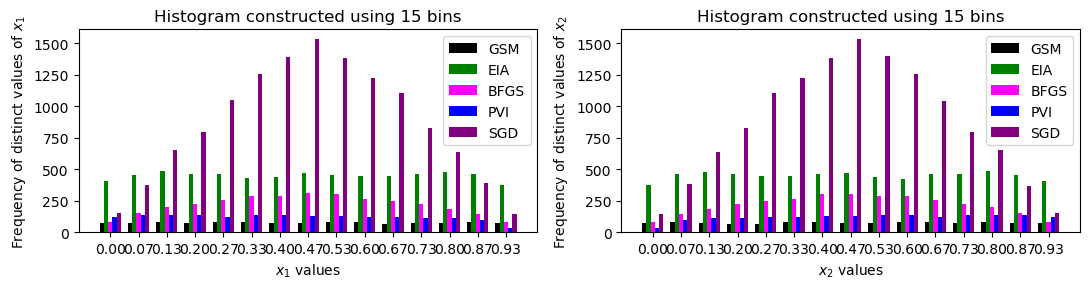

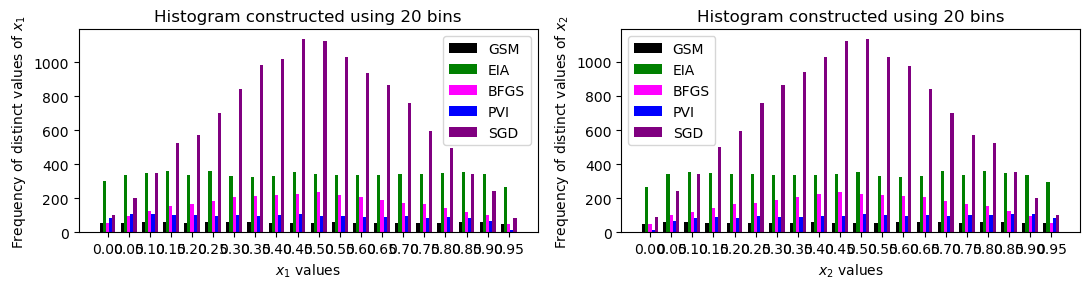

In [260]:
import matplotlib.pyplot as plt
import numpy as np

for n_bins in range(len(bins_list)):
    plt.figure(figsize=(11, 3))  # Increase the figure height for better readability
    
    width = 0.15  # Width of the bars
    
    # First subplot for x_hist_gsm and x_hist_eia
    plt.subplot(1, 2, 1)
    
    x = np.arange(len(x_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(x - 2*width, list(x_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(x - width, list(x_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(x, list(x_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(x + width, list(x_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(x + 2*width, list(x_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')
    
    # Customize plot
    plt.xticks(x, ["{:.2f}".format(b) for b in x_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_1$ values')
    plt.ylabel('Frequency of distinct values of $x_1$')
    plt.title('Histogram constructed using {} bins'.format(len(x_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.title('Histogram for n_bins= {}'.format(len(x_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    # Second subplot for y_hist_gsm and y_hist_eia
    plt.subplot(1, 2, 2)
    
    y = np.arange(len(y_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(y - 2*width, list(y_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(y - width, list(y_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(y, list(y_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(y + width, list(y_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(y + 2*width, list(y_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in y_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_2$ values')
    plt.ylabel('Frequency of distinct values of $x_2$')
    plt.title('Histogram constructed using {} bins'.format(len(y_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.title('Histogram for n_bins= {}'.format(len(y_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    plt.tight_layout()
    # Uncomment the next line to save the plot
    plt.savefig('../KS-Plots/Ex7/'+'ex7_hist_bin'+str(bins_list[n_bins])+'.png')
    plt.show()


In [261]:
Ex6Sols= {
        "EIA":
                {
                    "hd": None, "pdp": None, "solutions": None
                },

     "SGD":{
        "hd":None, "pdp": None, "solutions":None
    },

     "GSM":{
        "hd":None, "pdp": None, "solutions":None
    },

     "PVI":{
        "hd":None, "pdp": None, "solutions":None
    },

     "BFGS":{
        "hd":None, "pdp": None, "solutions":None
    }



}

Algorithms= ["EIA", "SGD", "GSM", "PVI", "BFGS"]

HDResults= [hdeia, hdsgd, hdgsm, hdgpvi, hdbfgs]
PDPResults= [pdpeia, pdpsgd, pdpgsm, pdppvi, pdpbfgs]
# dataSol= [data_eia, data_sgd, data_gsm, data_pvi, data_bfgs]

for (idx, algo) in enumerate(Algorithms):

    Ex6Sols[algo]["hd"]= HDResults[idx]
    Ex6Sols[algo]["pdp"]= PDPResults[idx]
    # Ex4Sols[algo]["solutions"]= dataSol[idx]


import json

def convert_ndarray(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("Ex6Sols.json", "w", encoding="utf-8") as f:
    json.dump(Ex6Sols, f, indent=4, default=convert_ndarray)


import json

with open("Ex6Sols.json", "r", encoding="utf-8") as f:
    Ex6Sols = json.load(f)

